In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("/content/restaurant.csv")

In [3]:
df=df[["stars","text"]]

In [4]:
df.isnull().sum()

,0
stars,0
text,0


In [5]:
df["text"] = df["text"].str.lower() # Metindeki tüm kelimeler küçük harfe dönüştürülür
df["text"] = df["text"].str.replace(r'[^\w\s]', ' ', regex=True)  # metindeki noktalama işaretleri ve özel karakterler (harf, rakam ve boşluk dışındaki) kaldırılır
df["text"] = df["text"].str.replace(r'\d+', '', regex=True)        # metindeki tüm rakamlar  silinir
df["text"] = df["text"].str.replace(r'\n', ' ', regex=True)         # satır atlama (newline) karakterleri kaldırılır
df["text"] = df["text"].str.replace(r',\r', ' ', regex=True)        # virgül ve ardından gelen carriage return karakterleri silinir
df["text"] = df["text"].str.replace(r'\s+', ' ', regex=True).str.strip() # fazladan boşlukları tek boşluk haline getir

In [8]:
import matplotlib.pyplot as plt
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

### Tokenization

In [9]:
from nltk.tokenize import word_tokenize
df['tokens'] = df['text'].apply(word_tokenize)
df[['text', 'tokens']].head()

,text,tokens
0,after getting food poisoning at the palms hote...,"[after, getting, food, poisoning, at, the, pal..."
1,a feast worthy of gods baccarnal buffet in cae...,"[a, feast, worthy, of, gods, baccarnal, buffet..."
2,the crab legs are better than the ones at wick...,"[the, crab, legs, are, better, than, the, ones..."
3,not worth it too salty food and expensive this...,"[not, worth, it, too, salty, food, and, expens..."
4,i would give this infinite stars if i could my...,"[i, would, give, this, infinite, stars, if, i,..."


### Stop‑word removal

In [10]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
df['filtered_tokens'] = df['tokens'].apply(lambda toks: [t for t in toks if t.lower() not in stop_words and t.isalnum()])
df[['text', 'filtered_tokens']].head()

,text,filtered_tokens
0,after getting food poisoning at the palms hote...,"[getting, food, poisoning, palms, hotel, scare..."
1,a feast worthy of gods baccarnal buffet in cae...,"[feast, worthy, gods, baccarnal, buffet, caesa..."
2,the crab legs are better than the ones at wick...,"[crab, legs, better, ones, wicked, spoon, huge..."
3,not worth it too salty food and expensive this...,"[worth, salty, food, expensive, furst, kast, v..."
4,i would give this infinite stars if i could my...,"[would, give, infinite, stars, could, family, ..."


### Stemming

In [11]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
df['stemmed'] = df['filtered_tokens'].apply(lambda toks: [stemmer.stem(t) for t in toks])
df[['text', 'stemmed']].head()

,text,stemmed
0,after getting food poisoning at the palms hote...,"[get, food, poison, palm, hotel, scare, eat, b..."
1,a feast worthy of gods baccarnal buffet in cae...,"[feast, worthi, god, baccarn, buffet, caesar, ..."
2,the crab legs are better than the ones at wick...,"[crab, leg, better, one, wick, spoon, huge, pr..."
3,not worth it too salty food and expensive this...,"[worth, salti, food, expens, furst, kast, visi..."
4,i would give this infinite stars if i could my...,"[would, give, infinit, star, could, famili, di..."


### Lemmatization

In [12]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
df['lemmatized'] = df['filtered_tokens'].apply(lambda toks: [lemmatizer.lemmatize(t.lower()) for t in toks])
df[['text', 'lemmatized']].head()

,text,lemmatized
0,after getting food poisoning at the palms hote...,"[getting, food, poisoning, palm, hotel, scared..."
1,a feast worthy of gods baccarnal buffet in cae...,"[feast, worthy, god, baccarnal, buffet, caesar..."
2,the crab legs are better than the ones at wick...,"[crab, leg, better, one, wicked, spoon, huge, ..."
3,not worth it too salty food and expensive this...,"[worth, salty, food, expensive, furst, kast, v..."
4,i would give this infinite stars if i could my...,"[would, give, infinite, star, could, family, d..."


### Sentiment Analysis

In [13]:
df.loc[df['stars']==3,"sentiment"]="neutral"
df.loc[df['stars']<3,"sentiment"]="negative"
df.loc[df['stars']>3,"sentiment"]="positive"

In [14]:
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

def sentiment_scores(text):
    score = sia.polarity_scores(text)
    return pd.Series([score['neg'], score['neu'], score['pos'], score['compound']],
                     index=['sent_neg', 'sent_neu', 'sent_pos', 'sent_comp'])

df[['sent_neg', 'sent_neu', 'sent_pos', 'sent_comp']] = df['text'].apply(sentiment_scores)
df[['text', 'sent_neg', 'sent_neu', 'sent_pos', 'sent_comp']].head()

,text,sent_neg,sent_neu,sent_pos,sent_comp
0,after getting food poisoning at the palms hote...,0.092,0.657,0.251,0.9902
1,a feast worthy of gods baccarnal buffet in cae...,0.094,0.749,0.157,0.9970
2,the crab legs are better than the ones at wick...,0.110,0.770,0.120,0.1027
3,not worth it too salty food and expensive this...,0.089,0.911,0.000,-0.1695
4,i would give this infinite stars if i could my...,0.031,0.739,0.230,0.9325


In [15]:
df.sample(3)

,stars,text,tokens,filtered_tokens,stemmed,lemmatized,sentiment,sent_neg,sent_neu,sent_pos,sent_comp
3357,5,always awesome when i come here the steamed cr...,"[always, awesome, when, i, come, here, the, st...","[always, awesome, come, steamed, crab, legs, s...","[alway, awesom, come, steam, crab, leg, sooooo...","[always, awesome, come, steamed, crab, leg, so...",positive,0.000,0.787,0.213,0.6705
8403,5,amazing presentation food is diverse and tasty...,"[amazing, presentation, food, is, diverse, and...","[amazing, presentation, food, diverse, tasty, ...","[amaz, present, food, divers, tasti, plu, hote...","[amazing, presentation, food, diverse, tasty, ...",positive,0.080,0.652,0.267,0.8225
5815,5,expensive but good no let down here the meat a...,"[expensive, but, good, no, let, down, here, th...","[expensive, good, let, meat, seafood, selectio...","[expens, good, let, meat, seafood, select, bes...","[expensive, good, let, meat, seafood, selectio...",positive,0.102,0.546,0.352,0.8338


### N‑gram extraction (bigram & trigram)

In [16]:
#Filtered Tokens - N-gram

In [17]:
from nltk.util import ngrams
df['bigrams']  = df['filtered_tokens'].apply(lambda toks: [' '.join(g) for g in ngrams(toks, 2)])
df['trigrams'] = df['filtered_tokens'].apply(lambda toks: [' '.join(g) for g in ngrams(toks, 3)])
df[['text','bigrams','trigrams']].head()

,text,bigrams,trigrams
0,after getting food poisoning at the palms hote...,"[getting food, food poisoning, poisoning palms...","[getting food poisoning, food poisoning palms,..."
1,a feast worthy of gods baccarnal buffet in cae...,"[feast worthy, worthy gods, gods baccarnal, ba...","[feast worthy gods, worthy gods baccarnal, god..."
2,the crab legs are better than the ones at wick...,"[crab legs, legs better, better ones, ones wic...","[crab legs better, legs better ones, better on..."
3,not worth it too salty food and expensive this...,"[worth salty, salty food, food expensive, expe...","[worth salty food, salty food expensive, food ..."
4,i would give this infinite stars if i could my...,"[would give, give infinite, infinite stars, st...","[would give infinite, give infinite stars, inf..."


In [18]:
# Text - N-gram

In [19]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

df['tokens'] = df['text'].apply(word_tokenize)
#kelime n-gram’lerini hesaplama
df['bigrams']  = df['tokens'].apply(lambda toks: [' '.join(g) for g in ngrams(toks, 2)])
df['trigrams'] = df['tokens'].apply(lambda toks: [' '.join(g) for g in ngrams(toks, 3)])

df[['text', 'bigrams', 'trigrams']].head()

,text,bigrams,trigrams
0,after getting food poisoning at the palms hote...,"[after getting, getting food, food poisoning, ...","[after getting food, getting food poisoning, f..."
1,a feast worthy of gods baccarnal buffet in cae...,"[a feast, feast worthy, worthy of, of gods, go...","[a feast worthy, feast worthy of, worthy of go..."
2,the crab legs are better than the ones at wick...,"[the crab, crab legs, legs are, are better, be...","[the crab legs, crab legs are, legs are better..."
3,not worth it too salty food and expensive this...,"[not worth, worth it, it too, too salty, salty...","[not worth it, worth it too, it too salty, too..."
4,i would give this infinite stars if i could my...,"[i would, would give, give this, this infinite...","[i would give, would give this, give this infi..."


In [20]:
# Lemmatized - N-gram

In [21]:
from nltk.util import ngrams
df['bigrams']  = df['lemmatized'].apply(lambda toks: [' '.join(g) for g in ngrams(toks, 2)])
df['trigrams'] = df['lemmatized'].apply(lambda toks: [' '.join(g) for g in ngrams(toks, 3)])
df[['text','bigrams','trigrams']].head()

,text,bigrams,trigrams
0,after getting food poisoning at the palms hote...,"[getting food, food poisoning, poisoning palm,...","[getting food poisoning, food poisoning palm, ..."
1,a feast worthy of gods baccarnal buffet in cae...,"[feast worthy, worthy god, god baccarnal, bacc...","[feast worthy god, worthy god baccarnal, god b..."
2,the crab legs are better than the ones at wick...,"[crab leg, leg better, better one, one wicked,...","[crab leg better, leg better one, better one w..."
3,not worth it too salty food and expensive this...,"[worth salty, salty food, food expensive, expe...","[worth salty food, salty food expensive, food ..."
4,i would give this infinite stars if i could my...,"[would give, give infinite, infinite star, sta...","[would give infinite, give infinite star, infi..."


### Pos Tagging

In [23]:
from nltk import pos_tag
import nltk
nltk.download('averaged_perceptron_tagger_eng')
df['pos_tags'] = df['filtered_tokens'].apply(pos_tag)
df[['text','filtered_tokens','pos_tags']].head()

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


,text,filtered_tokens,pos_tags
0,after getting food poisoning at the palms hote...,"[getting, food, poisoning, palms, hotel, scare...","[(getting, VBG), (food, NN), (poisoning, VBG),..."
1,a feast worthy of gods baccarnal buffet in cae...,"[feast, worthy, gods, baccarnal, buffet, caesa...","[(feast, NN), (worthy, JJ), (gods, NNS), (bacc..."
2,the crab legs are better than the ones at wick...,"[crab, legs, better, ones, wicked, spoon, huge...","[(crab, NN), (legs, NNS), (better, RBR), (ones..."
3,not worth it too salty food and expensive this...,"[worth, salty, food, expensive, furst, kast, v...","[(worth, NN), (salty, NN), (food, NN), (expens..."
4,i would give this infinite stars if i could my...,"[would, give, infinite, stars, could, family, ...","[(would, MD), (give, VB), (infinite, JJ), (sta..."


In [24]:
from nltk import pos_tag
from nltk.tokenize import word_tokenize

df['pos_tags_text'] = df['text'].apply(lambda x: pos_tag(word_tokenize(str(x))) if isinstance(x, str) else [])
df[['text', 'pos_tags_text']].head()

,text,pos_tags_text
0,after getting food poisoning at the palms hote...,"[(after, IN), (getting, VBG), (food, NN), (poi..."
1,a feast worthy of gods baccarnal buffet in cae...,"[(a, DT), (feast, JJ), (worthy, NN), (of, IN),..."
2,the crab legs are better than the ones at wick...,"[(the, DT), (crab, NN), (legs, NNS), (are, VBP..."
3,not worth it too salty food and expensive this...,"[(not, RB), (worth, IN), (it, PRP), (too, RB),..."
4,i would give this infinite stars if i could my...,"[(i, NN), (would, MD), (give, VB), (this, DT),..."


In [25]:
df.sample(6)

,stars,text,tokens,filtered_tokens,stemmed,lemmatized,sentiment,sent_neg,sent_neu,sent_pos,sent_comp,bigrams,trigrams,pos_tags,pos_tags_text
5200,4,bacchanal is now our new favorite buffet in lv...,"[bacchanal, is, now, our, new, favorite, buffe...","[bacchanal, new, favorite, buffet, lv, prior, ...","[bacchan, new, favorit, buffet, lv, prior, wic...","[bacchanal, new, favorite, buffet, lv, prior, ...",positive,0.034,0.880,0.086,0.3291,"[bacchanal new, new favorite, favorite buffet,...","[bacchanal new favorite, new favorite buffet, ...","[(bacchanal, JJ), (new, JJ), (favorite, JJ), (...","[(bacchanal, NN), (is, VBZ), (now, RB), (our, ..."
5165,5,omg this place is worth the also a very long w...,"[omg, this, place, is, worth, the, also, a, ve...","[omg, place, worth, also, long, wait, worth, u...","[omg, place, worth, also, long, wait, worth, u...","[omg, place, worth, also, long, wait, worth, u...",positive,0.072,0.721,0.207,0.9710,"[omg place, place worth, worth also, also long...","[omg place worth, place worth also, worth also...","[(omg, JJ), (place, NN), (worth, NN), (also, R...","[(omg, NN), (this, DT), (place, NN), (is, VBZ)..."
4182,5,my husband is not a fan of buffets but the res...,"[my, husband, is, not, a, fan, of, buffets, bu...","[husband, fan, buffets, rest, family, loves, p...","[husband, fan, buffet, rest, famili, love, pla...","[husband, fan, buffet, rest, family, love, pla...",positive,0.054,0.649,0.297,0.9766,"[husband fan, fan buffet, buffet rest, rest fa...","[husband fan buffet, fan buffet rest, buffet r...","[(husband, NN), (fan, NN), (buffets, NNS), (re...","[(my, PRP$), (husband, NN), (is, VBZ), (not, R..."
694,5,i have to say this is one of the best buffet r...,"[i, have, to, say, this, is, one, of, the, bes...","[say, one, best, buffet, restaurants, las, veg...","[say, one, best, buffet, restaur, la, vega, re...","[say, one, best, buffet, restaurant, la, vega,...",positive,0.000,0.744,0.256,0.9544,"[say one, one best, best buffet, buffet restau...","[say one best, one best buffet, best buffet re...","[(say, VB), (one, CD), (best, JJS), (buffet, N...","[(i, NNS), (have, VBP), (to, TO), (say, VB), (..."
8859,2,i tried every single items they had to offer i...,"[i, tried, every, single, items, they, had, to...","[tried, every, single, items, offer, live, exp...","[tri, everi, singl, item, offer, live, expect,...","[tried, every, single, item, offer, live, expe...",negative,0.087,0.834,0.079,0.5053,"[tried every, every single, single item, item ...","[tried every single, every single item, single...","[(tried, VBN), (every, DT), (single, JJ), (ite...","[(i, NN), (tried, VBD), (every, DT), (single, ..."
2298,4,one of the best buffets i ve ever been to i ha...,"[one, of, the, best, buffets, i, ve, ever, bee...","[one, best, buffets, ever, hate, admit, sin, f...","[one, best, buffet, ever, hate, admit, sin, fa...","[one, best, buffet, ever, hate, admit, sin, fa...",positive,0.079,0.708,0.213,0.9920,"[one best, best buffet, buffet ever, ever hate...","[one best buffet, best buffet ever, buffet eve...","[(one, CD), (best, JJS), (buffets, NNS), (ever...","[(one, CD), (of, IN), (the, DT), (best, JJS), ..."


In [26]:
df.to_csv('updated_yelp.csv', index=False)

In [27]:
df=pd.read_csv("updated_yelp.csv")

In [28]:
df.head(3)

,stars,text,tokens,filtered_tokens,stemmed,lemmatized,sentiment,sent_neg,sent_neu,sent_pos,sent_comp,bigrams,trigrams,pos_tags,pos_tags_text
0,5,after getting food poisoning at the palms hote...,"['after', 'getting', 'food', 'poisoning', 'at'...","['getting', 'food', 'poisoning', 'palms', 'hot...","['get', 'food', 'poison', 'palm', 'hotel', 'sc...","['getting', 'food', 'poisoning', 'palm', 'hote...",positive,0.092,0.657,0.251,0.9902,"['getting food', 'food poisoning', 'poisoning ...","['getting food poisoning', 'food poisoning pal...","[('getting', 'VBG'), ('food', 'NN'), ('poisoni...","[('after', 'IN'), ('getting', 'VBG'), ('food',..."
1,4,a feast worthy of gods baccarnal buffet in cae...,"['a', 'feast', 'worthy', 'of', 'gods', 'baccar...","['feast', 'worthy', 'gods', 'baccarnal', 'buff...","['feast', 'worthi', 'god', 'baccarn', 'buffet'...","['feast', 'worthy', 'god', 'baccarnal', 'buffe...",positive,0.094,0.749,0.157,0.9970,"['feast worthy', 'worthy god', 'god baccarnal'...","['feast worthy god', 'worthy god baccarnal', '...","[('feast', 'NN'), ('worthy', 'JJ'), ('gods', '...","[('a', 'DT'), ('feast', 'JJ'), ('worthy', 'NN'..."
2,4,the crab legs are better than the ones at wick...,"['the', 'crab', 'legs', 'are', 'better', 'than...","['crab', 'legs', 'better', 'ones', 'wicked', '...","['crab', 'leg', 'better', 'one', 'wick', 'spoo...","['crab', 'leg', 'better', 'one', 'wicked', 'sp...",positive,0.110,0.770,0.120,0.1027,"['crab leg', 'leg better', 'better one', 'one ...","['crab leg better', 'leg better one', 'better ...","[('crab', 'NN'), ('legs', 'NNS'), ('better', '...","[('the', 'DT'), ('crab', 'NN'), ('legs', 'NNS'..."


In [29]:
# Helper to convert list-like columns to plain text
import ast; list_to_text = lambda s: s.apply(lambda x: ' '.join(map(str, x if isinstance(x, list) else ast.literal_eval(x) if isinstance(x, str) and x[:1]=='[' and x[-1:]==']' else [x])))

## Modelling

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [31]:
def run_models(text_series, y):
    # Metin verisini düz metin haline getir
    X = list_to_text(text_series)


    # Eğitim ve test bölmesi
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # TF-IDF vektörleştiricisi
    vectorizer = TfidfVectorizer(ngram_range=(1,2))
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec  = vectorizer.transform(X_test)

    # Tüm modelleri içeren sözlük
    models = {
        'LogReg':        LogisticRegression(max_iter=1000),
        'KNN':           KNeighborsClassifier(),
        'DecisionTree':  DecisionTreeClassifier(),
        'RandomForest':  RandomForestClassifier(),
        'AdaBoost':      AdaBoostClassifier(),
        'GradBoost':     GradientBoostingClassifier(),
        'MultinomialNB': MultinomialNB(),
        'BernoulliNB':   BernoulliNB()
    }

    # Her model için eğitim, tahmin ve metrik hesaplama
    rows = []
    for name, model in models.items():
        model.fit(X_train_vec, y_train)
        preds = model.predict(X_test_vec)
        rows.append({
            'Model':     name,
            'Accuracy':  round(accuracy_score(y_test, preds), 3),
            'Precision': round(precision_score(y_test, preds, average='macro'), 3),
            'Recall':    round(recall_score(y_test, preds, average='macro'), 3),
            'F1':        round(f1_score(y_test, preds, average='macro'), 3)
        })

    res = pd.DataFrame(rows).set_index('Model')
    display(res)
    return res

In [32]:
df.sample(2)

,stars,text,tokens,filtered_tokens,stemmed,lemmatized,sentiment,sent_neg,sent_neu,sent_pos,sent_comp,bigrams,trigrams,pos_tags,pos_tags_text
7424,4,excellent buffet food selections galore why di...,"['excellent', 'buffet', 'food', 'selections', ...","['excellent', 'buffet', 'food', 'selections', ...","['excel', 'buffet', 'food', 'select', 'galor',...","['excellent', 'buffet', 'food', 'selection', '...",positive,0.084,0.752,0.164,0.4408,"['excellent buffet', 'buffet food', 'food sele...","['excellent buffet food', 'buffet food selecti...","[('excellent', 'JJ'), ('buffet', 'NN'), ('food...","[('excellent', 'JJ'), ('buffet', 'NN'), ('food..."
3085,5,bachhanal prides itself on being the largest b...,"['bachhanal', 'prides', 'itself', 'on', 'being...","['bachhanal', 'prides', 'largest', 'buffet', '...","['bachhan', 'pride', 'largest', 'buffet', 'veg...","['bachhanal', 'pride', 'largest', 'buffet', 'v...",positive,0.034,0.901,0.064,0.6955,"['bachhanal pride', 'pride largest', 'largest ...","['bachhanal pride largest', 'pride largest buf...","[('bachhanal', 'JJ'), ('prides', 'NNS'), ('lar...","[('bachhanal', 'JJ'), ('prides', 'NNS'), ('its..."


In [33]:
results_stem = run_models(df["stemmed"], df['sentiment'])

,Accuracy,Precision,Recall,F1
Model,,,,
LogReg,0.800,0.722,0.606,0.629
KNN,0.729,0.566,0.540,0.541
DecisionTree,0.666,0.519,0.512,0.515
RandomForest,0.703,0.793,0.410,0.398
AdaBoost,0.707,0.608,0.437,0.446
GradBoost,0.774,0.698,0.565,0.599
MultinomialNB,0.661,0.220,0.333,0.265
BernoulliNB,0.667,0.585,0.350,0.301


In [34]:
results_lemma = run_models(df["lemmatized"], df['sentiment'])

,Accuracy,Precision,Recall,F1
Model,,,,
LogReg,0.797,0.711,0.601,0.621
KNN,0.729,0.561,0.527,0.529
DecisionTree,0.653,0.499,0.495,0.497
RandomForest,0.706,0.783,0.415,0.405
AdaBoost,0.679,0.599,0.408,0.405
GradBoost,0.775,0.714,0.569,0.604
MultinomialNB,0.661,0.220,0.333,0.265
BernoulliNB,0.665,0.610,0.344,0.288


In [36]:
import seaborn as sns
from collections import Counter
import ast

# 1. Eğer içlerinde liste değil de string varsa listeye çevir
df['bigrams'] = df['bigrams'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df['trigrams'] = df['trigrams'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 2. Bütün bigram ve trigramları birleştir
all_bigrams = sum(df['bigrams'].tolist(), [])
all_trigrams = sum(df['trigrams'].tolist(), [])

# 3. Sayım yap
bigram_counts = Counter(all_bigrams)
trigram_counts = Counter(all_trigrams)

# 4. En sık geçen 10 bigram ve trigram
top_bigrams = bigram_counts.most_common(10)
top_trigrams = trigram_counts.most_common(10)

# 5. DataFrame'e çevir
bigram_df = pd.DataFrame(top_bigrams, columns=['Bigram', 'Count'])
trigram_df = pd.DataFrame(top_trigrams, columns=['Trigram', 'Count'])

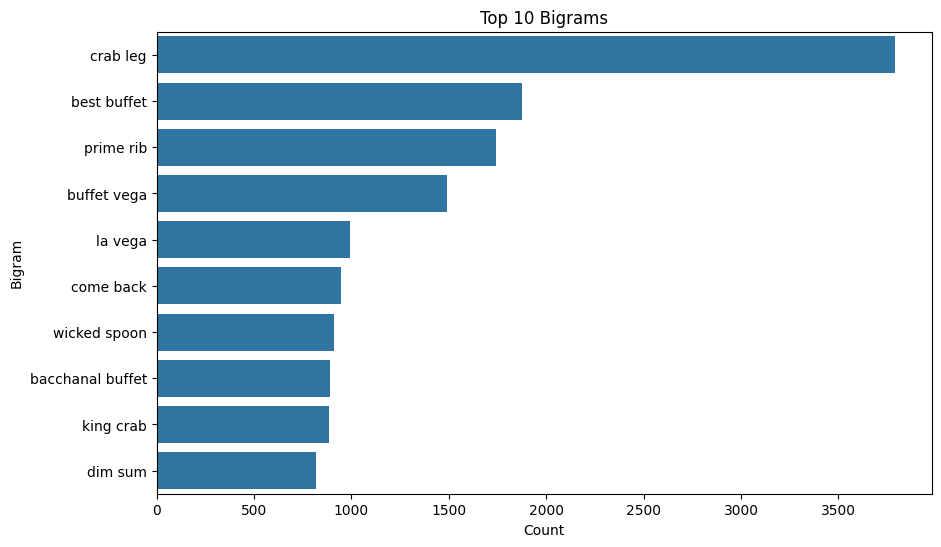

In [37]:
plt.figure(figsize=(10,6))
sns.barplot(data=bigram_df, y='Bigram', x='Count')
plt.title('Top 10 Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()

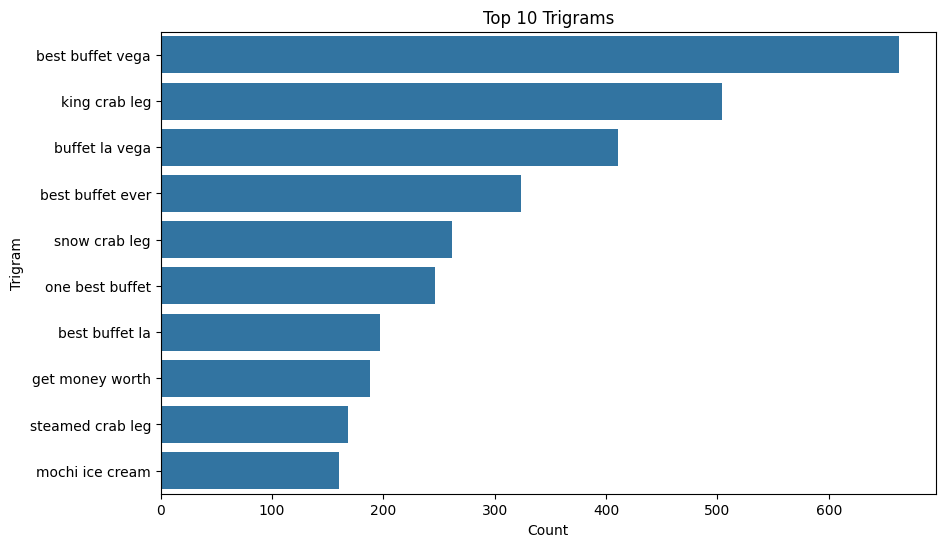

In [38]:
plt.figure(figsize=(10,6))
sns.barplot(data=trigram_df, y='Trigram', x='Count')
plt.title('Top 10 Trigrams')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.show()

## Worcloud

In [39]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [40]:
cloud_mask = np.array(Image.open("/content/cloud.png"))

In [41]:
wc_5 = WordCloud(width=500, height=350, background_color='white', mask=cloud_mask).generate(" ".join(df[df["stars"]==5]["text"]))
wc_1 = WordCloud(width=500, height=350, background_color='red', mask=cloud_mask).generate(" ".join(df[df["stars"]==1]["text"]))

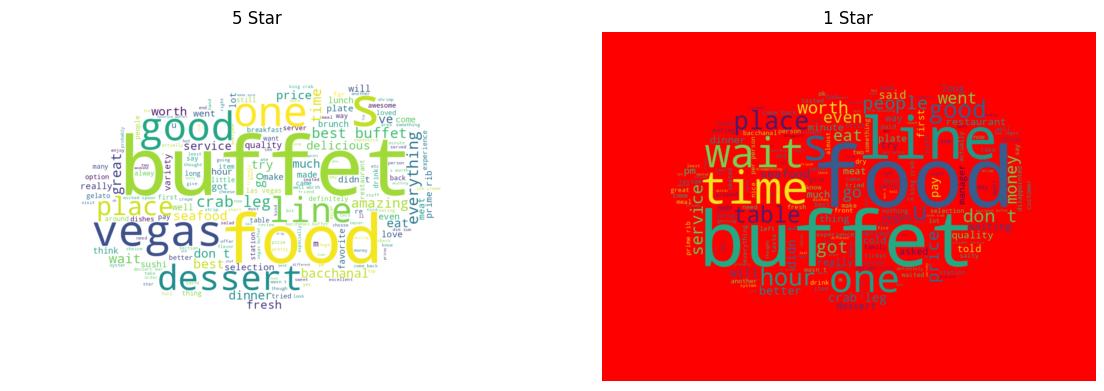

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(wc_5, interpolation='bilinear')
ax[0].axis("off")
ax[0].set_title("5 Star")

ax[1].imshow(wc_1, interpolation='bilinear')
ax[1].axis("off")
ax[1].set_title("1 Star");

In [43]:
wc_pos = WordCloud(width=500, height=350, background_color='white', mask=cloud_mask).generate(" ".join(df[df["sentiment"] == "positive"]["text"]))
wc_neg = WordCloud(width=500, height=350, background_color='red', mask=cloud_mask).generate(" ".join(df[df["sentiment"] == "negative"]["text"]))

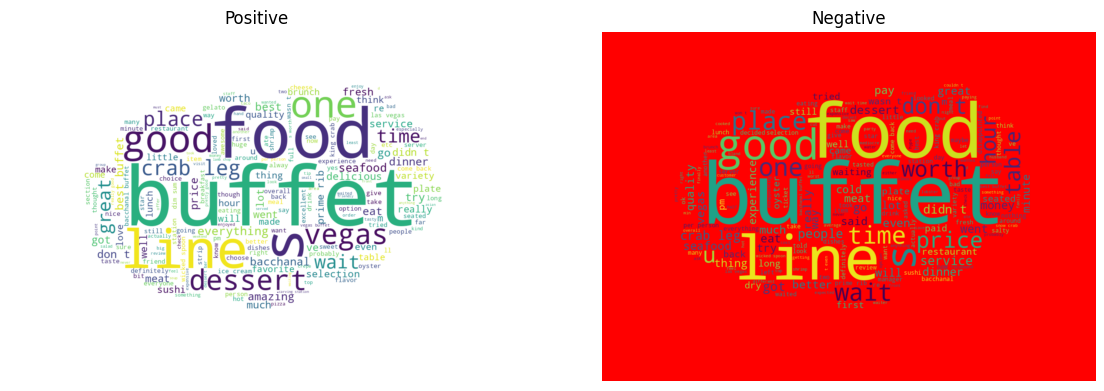

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(wc_pos, interpolation='bilinear')
ax[0].axis("off")
ax[0].set_title("Positive")

ax[1].imshow(wc_neg, interpolation='bilinear')
ax[1].axis("off")
ax[1].set_title("Negative");